In [3]:
import xarray as xr

In [4]:
# data = xr.open_zarr(
#     "/vast/sd5313/data/m2lines/3D_ocean_data/OM4_Horizontal_Regrid_Old.zarr"
# )

data = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr"
)

# data = xr.open_zarr(
#     "/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1_fast_smoothed_30.zarr"
# )

# data = xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/test_CMIP6_GFDL-CM4.piControl.r1i1p1f1.zarr")

In [17]:
data

<xarray.Dataset>
Dimensions:         (y: 180, x: 360, lev: 19, time: 4745, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time            (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(594, 3, 23, 45), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(594, 3, 23, 45), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

### Convert and save 3D data for training

Make sure you are using atleast 10 cores!

In [18]:
from dask.diagnostics import ProgressBar

In [19]:
# import numpy as np
# def manual_v0_fixes(ds_input: xr.Dataset) -> xr.Dataset:
#     """Manual fixes for the already existing data (for now only v0.0). This should not be used in the future"""
#     # fixes that should be checked and fixes on the input data
#     # area = xr.open_dataset(
#     #     "gs://leap-persistent/sd5313/grids_CM2x.zarr", engine="zarr", chunks={}
#     # )["area_C"].rename({"xu_ocean": "x", "yu_ocean": "y"})
#     # print("area", area)
#     # area = xr.open_dataset("/vast/sd5313/data/m2lines/3D_ocean_data/Grid_New.nc")["area_C"].rename({"xu_ocean": "x", "yu_ocean": "y"})
#     # print("area", area)
#     # from https://github.com/m2lines/ocean_emulators/issues/17
#     dz = xr.DataArray(
#         [
#             5,
#             10,
#             15,
#             20,
#             30,
#             50,
#             70,
#             100,
#             150,
#             200,
#             250,
#             300,
#             400,
#             500,
#             600,
#             800,
#             1000,
#             1000,
#             1000,
#         ],
#         dims=["lev"],
#     )
#     z = xr.DataArray(
#         [
#             2.5,
#             10,
#             22.5,
#             40,
#             65,
#             105,
#             165,
#             250,
#             375,
#             550,
#             775,
#             1050,
#             1400,
#             1850,
#             2400,
#             3100,
#             4000,
#             5000,
#             6000,
#         ],
#         dims="lev",
#     )
#     wetmask = ~np.isnan(ds_input.thetao.isel(time=0).reset_coords(drop=True)).load()
#     # lon = xr.ones_like(ds_input.y) * ds_input.x
#     # lat = ds_input.y * xr.ones_like(ds_input.x)
#     # ds_input = ds_input.assign_coords(
#     #     areacello=area, dz=dz, lev=z, wetmask=wetmask, lon=lon, lat=lat
#     # )
#     ds_input = ds_input.assign_coords(
#         dz=dz, lev=z, wetmask=wetmask
#     )
#     # give a dummy commit hash
#     ds_input.attrs["m2lines/ocean-emulators_git_hash"] = "dummy"
#     return ds_input

# data = manual_v0_fixes(data)

In [20]:
ds = data
ds

<xarray.Dataset>
Dimensions:         (y: 180, x: 360, lev: 19, time: 4745, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time            (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(594, 3, 23, 45), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(594, 3, 23, 45), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [21]:
ds["lev"]

<xarray.DataArray 'lev' (lev: 19)>
array([2.50e+00, 1.00e+01, 2.25e+01, 4.00e+01, 6.50e+01, 1.05e+02, 1.65e+02,
       2.50e+02, 3.75e+02, 5.50e+02, 7.75e+02, 1.05e+03, 1.40e+03, 1.85e+03,
       2.40e+03, 3.10e+03, 4.00e+03, 5.00e+03, 6.00e+03])
Coordinates:
    dz       (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
  * lev      (lev) float64 2.5 10.0 22.5 40.0 65.0 ... 3.1e+03 4e+03 5e+03 6e+03

In [22]:
assert [str(lev).replace(".", "_") for lev in ds["lev"].values] == ['2_5', '10_0', '22_5', '40_0', '65_0', '105_0', '165_0', '250_0', '375_0', '550_0', '775_0', '1050_0', '1400_0', '1850_0', '2400_0', '3100_0', '4000_0', '5000_0', '6000_0']

In [23]:
for lev in ds["lev"].values:
    lev_str = str(lev).replace(".", "_")

    # Create new variables for each original variable with the lev dimension
    ds[f"vo_lev_{lev_str}"] = ds["vo"].sel(lev=lev)
    ds[f"thetao_lev_{lev_str}"] = ds["thetao"].sel(lev=lev)
    ds[f"uo_lev_{lev_str}"] = ds["uo"].sel(lev=lev)
    ds[f"so_lev_{lev_str}"] = ds["so"].sel(lev=lev)

ds = ds.drop_vars(["vo", "thetao", "uo", "so"])
ds

<xarray.Dataset>
Dimensions:            (y: 180, x: 360, lev: 19, time: 4745, y_b: 181, x_b: 361)
Coordinates:
    areacello          (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz                 (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat                (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b              (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev                (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon                (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b              (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction     (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time               (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
    wetmask            (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x                  (x) float64 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * y                  (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables: (12/80)
    hfds               (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauuo              (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo              (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    zos                (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_2_5         (time, y, x) float32 dask.array<chunksize=(594, 23, 45), meta=np.ndarray>
    thetao_lev_2_5     (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...                 ...
    uo_lev_5000_0      (time, y, x) float32 dask.array<chunksize=(594, 23, 45), meta=np.ndarray>
    so_lev_5000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_6000_0      (time, y, x) float32 dask.array<chunksize=(594, 23, 45), meta=np.ndarray>
    thetao_lev_6000_0  (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    uo_lev_6000_0      (time, y, x) float32 dask.array<chunksize=(594, 23, 45), meta=np.ndarray>
    so_lev_6000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [24]:
with ProgressBar():
    ds_mean = ds.mean().compute()

[########################################] | 100% Completed | 240.73 s


In [30]:
ds_mean.to_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/3D_data_OM4_5daily_v0.2.1_fast_smoothed_30_means", encoding = {v:{'compressor':None} for v in ds_mean.variables},
                consolidated=True, mode='w')

In [26]:
with ProgressBar():
    ds_std = ds.std().compute()

[########################################] | 100% Completed | 323.02 s


In [31]:
ds_std.to_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/3D_data_OM4_5daily_v0.2.1_fast_smoothed_30_stds", encoding = {v:{'compressor':None} for v in ds_std.variables},
                consolidated=True, mode='w')

In [32]:
with ProgressBar():
    ds.to_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/3D_data_OM4_5daily_v0.2.1_fast_smoothed_30", encoding = {v:{'compressor':None} for v in ds.variables},
                consolidated=True, mode='w')

[########################################] | 100% Completed | 219.30 s


#### Wet mask

In [1]:
import xarray as xr

In [2]:
data = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr"
)

# import numpy as np
# def manual_v0_fixes(ds_input: xr.Dataset) -> xr.Dataset:
#     """Manual fixes for the already existing data (for now only v0.0). This should not be used in the future"""
#     # fixes that should be checked and fixes on the input data
#     # area = xr.open_dataset(
#     #     "gs://leap-persistent/sd5313/grids_CM2x.zarr", engine="zarr", chunks={}
#     # )["area_C"].rename({"xu_ocean": "x", "yu_ocean": "y"})
#     # print("area", area)
#     # area = xr.open_dataset("/vast/sd5313/data/m2lines/3D_ocean_data/Grid_New.nc")["area_C"].rename({"xu_ocean": "x", "yu_ocean": "y"})
#     # print("area", area)
#     # from https://github.com/m2lines/ocean_emulators/issues/17
#     dz = xr.DataArray(
#         [
#             5,
#             10,
#             15,
#             20,
#             30,
#             50,
#             70,
#             100,
#             150,
#             200,
#             250,
#             300,
#             400,
#             500,
#             600,
#             800,
#             1000,
#             1000,
#             1000,
#         ],
#         dims=["lev"],
#     )
#     z = xr.DataArray(
#         [
#             2.5,
#             10,
#             22.5,
#             40,
#             65,
#             105,
#             165,
#             250,
#             375,
#             550,
#             775,
#             1050,
#             1400,
#             1850,
#             2400,
#             3100,
#             4000,
#             5000,
#             6000,
#         ],
#         dims="lev",
#     )
#     wetmask = ~np.isnan(ds_input.thetao.isel(time=0).reset_coords(drop=True)).load()
#     # lon = xr.ones_like(ds_input.y) * ds_input.x
#     # lat = ds_input.y * xr.ones_like(ds_input.x)
#     # ds_input = ds_input.assign_coords(
#     #     areacello=area, dz=dz, lev=z, wetmask=wetmask, lon=lon, lat=lat
#     # )
#     ds_input = ds_input.assign_coords(
#         dz=dz, lev=z, wetmask=wetmask
#     )
#     # give a dummy commit hash
#     ds_input.attrs["m2lines/ocean-emulators_git_hash"] = "dummy"
#     return ds_input

# data = manual_v0_fixes(data)

levels = 5
# data = xr.open_zarr(
#     "/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr"
# )
# data = xr.open_zarr(
#     "/vast/sd5313/data/m2lines/3D_ocean_data/test_CMIP6_GFDL-CM4.piControl.r1i1p1f1.zarr"
# )
data

<xarray.Dataset>
Dimensions:         (y: 180, x: 360, lev: 19, time: 4745, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time            (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [3]:
data = data.drop(["tauuo", "tauvo", "hfds"])
# data = data.drop(["tauuo", "tauvo", "hft"])
data

<xarray.Dataset>
Dimensions:         (y: 180, x: 360, lev: 19, y_b: 181, x_b: 361, time: 4745)
Coordinates:
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time            (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    so              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [4]:
import numpy as np
import torch


def get_wet_mask(inputs, device="cpu"):
    wet = xr.zeros_like(inputs[0][0])
    # inputs[0][0,12,12] = np.nan
    for data in inputs:
        wet += np.isnan(data[0])

    wet_nan = xr.where(wet != 0, np.nan, 1).to_numpy()
    wet = np.isnan(xr.where(wet == 0, np.nan, 0))
    wet = np.nan_to_num(wet.to_numpy())
    wet = torch.from_numpy(wet).type(torch.float32).to(device=device)
    return wet, wet_nan

In [5]:
data.lev.values

array([2.50e+00, 1.00e+01, 2.25e+01, 4.00e+01, 6.50e+01, 1.05e+02,
       1.65e+02, 2.50e+02, 3.75e+02, 5.50e+02, 7.75e+02, 1.05e+03,
       1.40e+03, 1.85e+03, 2.40e+03, 3.10e+03, 4.00e+03, 5.00e+03,
       6.00e+03])

In [7]:
wet_stacked = []
for i, lev in enumerate(data["lev"].values[:levels]):
    inputs = []
    inputs.append(data["uo"].sel(lev=lev))
    inputs.append(data["vo"].sel(lev=lev))
    inputs.append(data["thetao"].sel(lev=lev))
    inputs.append(data["so"].sel(lev=lev))
    if i == 0:
        inputs.append(data["zos"])

    inputs = tuple(inputs)
    wet, _ = get_wet_mask(inputs)
    wet_stacked.append(wet)

In [8]:
wet_3D = torch.stack(wet_stacked)
wet_3D.shape

torch.Size([5, 180, 360])

In [7]:
import numpy as np
import torch

# Experiment inputs and outputs
DEPTH_LEVELS = ['2_5',
 '10_0',
 '22_5',
 '40_0',
 '65_0',
 '105_0',
 '165_0',
 '250_0',
 '375_0',
 '550_0',
 '775_0',
 '1050_0',
 '1400_0',
 '1850_0',
 '2400_0',
 '3100_0',
 '4000_0',
 '5000_0',
 '6000_0']

INPT_VARS = {
    "1": ["um", "vm"],
    "2": ["um", "vm", "ur", "vr"],
    "3": ["um", "vm", "Tm"],
    "4": ["um", "vm", "ur", "vr", "Tm", "Tr"],
    "5": ["ur", "vr"],
    "6": ["ur", "vr", "Tr"],
    "7": ["Tm"],
    "8": ["Tm", "Tr"],
    "9": ["u", "v"],
    "10": ["u", "v", "T"],
    "11": ["tau_u", "tau_v"],
    "12": ["tau_u", "tau_v", "t_ref"],
    "3D": ["uo", "vo", "thetao", "so", "zos"],
    "2D": [k + DEPTH_LEVELS[0]
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
    ]
    + ["zos"],
    "3D_5": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS[:5]
    ]
    + ["zos"],
    "3D_all": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS
    ]
    + ["zos"],
    "3D_SST_all": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS if not (k == "thetao_lev_" and j == DEPTH_LEVELS[0]) 
    ] 
    + ["zos"],
}
EXTRA_VARS = {
    "1": ["ur", "vr"],
    "2": ["ur", "vr", "Tm"],
    "3": ["Tm"],
    "4": ["ur", "vr", "Tm", "Tr"],
    "5": [],
    "6": ["um", "vm"],
    "7": ["um", "vm", "Tm"],
    "8": ["um", "vm", "Tm", "Tr"],
    "9": ["ur", "vr", "tau_u", "tau_v"],
    "10": ["tau_u", "tau_v"],
    "11": ["t_ref"],
    "12": ["tau_u", "tau_v", "t_ref"],
    "13": ["ur", "vr", "Tr", "tau_u", "tau_v", "t_ref"],
    "3D": ["tauuo", "tauvo", "hfds"],
    "2D": ["tauuo", "tauvo", "hfds"],
    "3D_5": ["tauuo", "tauvo", "hfds"],
    "3D_all": ["tauuo", "tauvo", "hfds"],
    "3D_SST_all": ["tauuo", "tauvo", "hfds", "thetao_lev_0"],
}
OUT_VARS = {
    "1": ["um", "vm"],
    "2": ["um", "vm", "Tm"],
    "3": ["ur", "vr"],
    "4": ["ur", "vr", "Tr"],
    "5": ["u", "v"],
    "6": ["u", "v", "T"],
    "3D": ["uo", "vo", "thetao", "so", "zos"],
    "2D": [k + DEPTH_LEVELS[0]
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
    ]
    + ["zos"],
    "3D_5": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS[:5]
    ]
    + ["zos"],
    "3D_noFast_5": [
        k + str(j)
        for k in ["thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS[:5]
    ]
    + ["zos"],
    "3D_all": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS
    ]
    + ["zos"],
    "3D_SST_all": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS if not (k == "thetao_lev_" and j == DEPTH_LEVELS[0]) 
    ] 
    + ["zos"],
}

In [11]:
out_list = INPT_VARS["3D_5"]
lev_map = {str(lev).replace('.', '_'): i for i, lev in enumerate(data["lev"].values)}
# print(out_list[:38] + out_list[39:])

In [12]:
out_list[0].split("lev_")[-1]

'2_5'

In [13]:
final_wet = []
for var in out_list:
    try:
        level = lev_map[var.split("lev_")[-1]]
        print(var, level)
    except Exception as e:
        level = 0
    final_wet.append(wet_3D[level])

uo_lev_2_5 0
uo_lev_10_0 1
uo_lev_22_5 2
uo_lev_40_0 3
uo_lev_65_0 4
vo_lev_2_5 0
vo_lev_10_0 1
vo_lev_22_5 2
vo_lev_40_0 3
vo_lev_65_0 4
thetao_lev_2_5 0
thetao_lev_10_0 1
thetao_lev_22_5 2
thetao_lev_40_0 3
thetao_lev_65_0 4
so_lev_2_5 0
so_lev_10_0 1
so_lev_22_5 2
so_lev_40_0 3
so_lev_65_0 4


In [14]:
wet = torch.stack(final_wet)
wet.shape

torch.Size([21, 180, 360])

In [15]:
assert wet.shape[0] == (levels * 4 + 1)

In [79]:
# wet = torch.cat([wet[:38], wet[39:]], axis=0)
# wet.shape

In [16]:
torch.save(wet, "/vast/sd5313/data/m2lines/3D_ocean_data/3D_wet_OM4_v0.2.1_5levels.pt")

### Convert and save surface data

Make sure you are using atleast 8 cores!

In [81]:
import sys

sys.path.append("../src/")

In [82]:
from utils.data_utils import get_wet_mask

In [83]:
inputs = []
inputs.append(data["uo"].sel(lev=2.5))
inputs.append(data["vo"].sel(lev=2.5))
inputs.append(data["thetao"].sel(lev=2.5))
inputs.append(data["so"].sel(lev=2.5))
inputs.append(data["zos"])
inputs = tuple(inputs)
wet, _ = get_wet_mask(inputs)
print("Wet resolution:", wet.shape)

Wet resolution: torch.Size([180, 360])


In [84]:
# print("Calculating mask tensors")
# wet, wet_nan = get_wet_mask(inputs, "cpu")
# # wet_bool = np.array(wet.cpu()).astype(bool)
# # wet_lap = compute_laplacian_wet(wet_nan, 4)  # hardcoded
# # wet_lap = xr.where(wet_lap == 0, 1, np.nan)
# # wet_lap = np.nan_to_num(wet_lap)
# print("Wet resolution:", wet.shape)

In [85]:
import torch

In [86]:
torch.save(wet, "/vast/sd5313/data/m2lines/3D_ocean_data/surface_wet_OM4_v0.0.pt")

#### Extra for surface training

In [ ]:
from dask.diagnostics import ProgressBar

In [ ]:
with ProgressBar():
    data_mean = data.mean().compute()

[########################################] | 100% Completed | 259.26 s


In [ ]:
data_mean.to_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/surface_data_means")

In [ ]:
with ProgressBar():
    data_std = data.std().compute()

[########################################] | 100% Completed | 244.16 s


In [ ]:
data_std.to_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/surface_data_stds")

In [ ]:
data.to_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/surface_data")

### Test

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar

In [2]:
data = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr"
)
# Save wet mask
# wet = data.wetmask
# wet.to_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1_wetmask")



In [19]:
def profile_mean(ds: xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello).mean(["x", "y"])

with ProgressBar():
    profile_groundtruth = profile_mean(data).load()


[########################################] | 100% Completed | 233.10 s


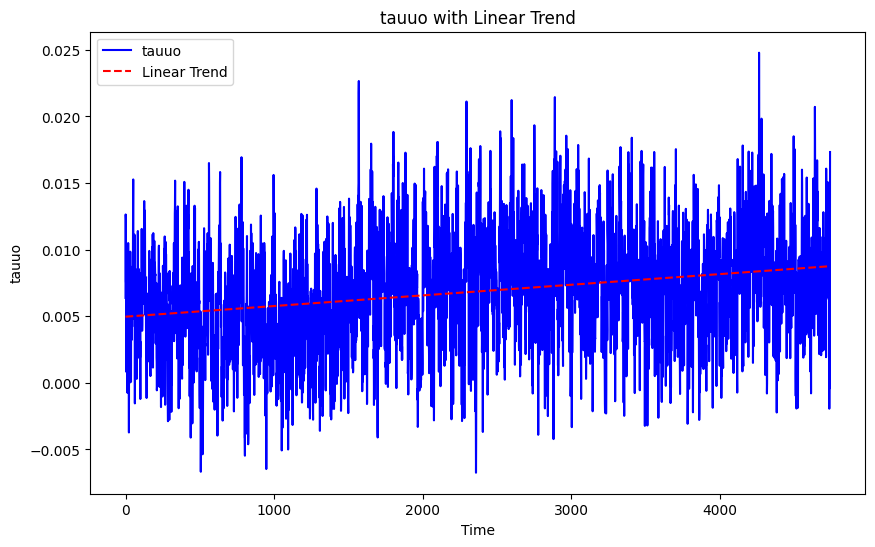

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'hfds' is your xarray DataArray with time as the coordinate
time = range(len(profile_groundtruth.time.values))
hfds = profile_groundtruth.tauuo.values

# Perform a linear fit (1st degree polynomial)
coefficients = np.polyfit(time, hfds, 1)
trend = np.polyval(coefficients, time)

# Plot the original data
plt.figure(figsize=(10, 6))
plt.plot(time, hfds, label='tauuo', color='blue')

# Plot the linear trend
plt.plot(time, trend, label='Linear Trend', color='red', linestyle='--')

plt.xlabel('Time')
plt.ylabel('tauuo')
plt.title('tauuo with Linear Trend')
plt.legend()
plt.show()

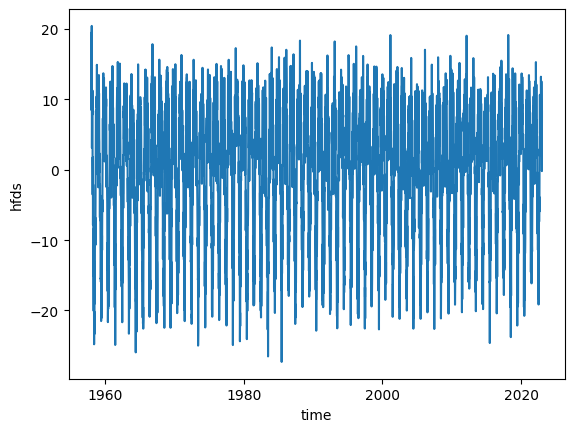

In [73]:
profile_groundtruth.hfds.plot()

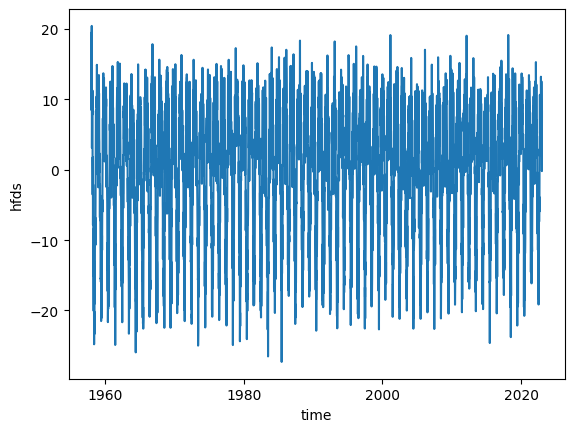

In [53]:
profile_groundtruth.hfds.plot()

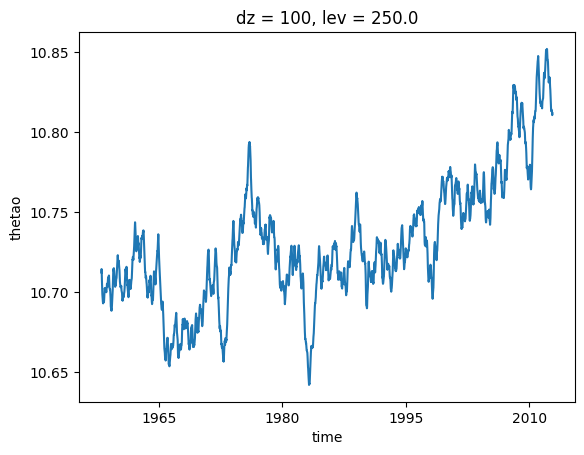

In [81]:
import matplotlib.ticker as plticker

fig, ax = plt.subplots()
profile_groundtruth.isel(lev=7).isel(time=slice(None,4000)).thetao.plot() # .isel(time=slice(-600,None))
# loc = plticker.MultipleLocator(base=4000.0) # this locator puts ticks at regular intervals
# ax.xaxis.set_major_locator(loc)
plt.show()

In [4]:
data.y

<xarray.DataArray 'y' (y: 180)>
array([-89.236642, -88.247774, -87.253067, -86.25704 , -85.260513, -84.263743,
       -83.266838, -82.26985 , -81.272807, -80.275726, -79.278618, -78.281489,
       -77.284345, -76.287188, -75.290022, -74.292847, -73.295667, -72.29848 ,
       -71.30129 , -70.304095, -69.306897, -68.309697, -67.312494, -66.315288,
       -65.318081, -64.320872, -63.323662, -62.326451, -61.329238, -60.332024,
       -59.334809, -58.337594, -57.340377, -56.34316 , -55.345942, -54.348724,
       -53.351505, -52.354286, -51.357066, -50.359845, -49.362625, -48.365404,
       -47.368182, -46.370961, -45.373739, -44.376516, -43.379294, -42.382071,
       -41.384848, -40.387625, -39.390401, -38.393178, -37.395954, -36.39873 ,
       -35.401506, -34.404282, -33.407057, -32.409833, -31.412608, -30.415383,
       -29.418159, -28.420934, -27.423709, -26.426484, -25.429258, -24.432033,
       -23.434808, -22.437582, -21.440357, -20.443131, -19.445906, -18.44868 ,
       -17.451454, -16.454229, -15.457003, -14.459777, -13.462551, -12.465325,
       -11.468099, -10.470874,  -9.473648,  -8.476422,  -7.479196,  -6.481969,
        -5.484743,  -4.487517,  -3.490291,  -2.493065,  -1.495839,  -0.498613,
         0.498613,   1.495839,   2.493065,   3.490291,   4.487517,   5.484743,
         6.481969,   7.479196,   8.476422,   9.473648,  10.470874,  11.468099,
        12.465325,  13.462551,  14.459777,  15.457003,  16.454229,  17.451454,
        18.44868 ,  19.445906,  20.443131,  21.440357,  22.437582,  23.434808,
        24.432033,  25.429258,  26.426484,  27.423709,  28.420934,  29.418159,
        30.415383,  31.412608,  32.409833,  33.407057,  34.404282,  35.401506,
        36.39873 ,  37.395954,  38.393178,  39.390401,  40.387625,  41.384848,
        42.382071,  43.379294,  44.376516,  45.373739,  46.370961,  47.368182,
        48.365404,  49.362625,  50.359845,  51.357066,  52.354286,  53.351505,
        54.348724,  55.345942,  56.34316 ,  57.340377,  58.337594,  59.334809,
        60.332024,  61.329238,  62.326451,  63.323662,  64.320872,  65.318081,
        66.315288,  67.312494,  68.309697,  69.306897,  70.304095,  71.30129 ,
        72.29848 ,  73.295667,  74.292847,  75.290022,  76.287188,  77.284345,
        78.281489,  79.278618,  80.275726,  81.272807,  82.26985 ,  83.266838,
        84.263743,  85.260513,  86.25704 ,  87.253067,  88.247774,  89.236642])
Coordinates:
  * y        (y) float64 -89.24 -88.25 -87.25 -86.26 ... 86.26 87.25 88.25 89.24
Attributes:
    long_name:  Latitude cell midpoint
    units:      degrees

In [9]:
data_loc = data.sel(x=slice(190, 200), y=slice(75,85))
location="Equatorial Pacific"
data_loc_single = data_loc.isel(x=5,y=5).isel(lev=0).isel(time=slice(None, 144))

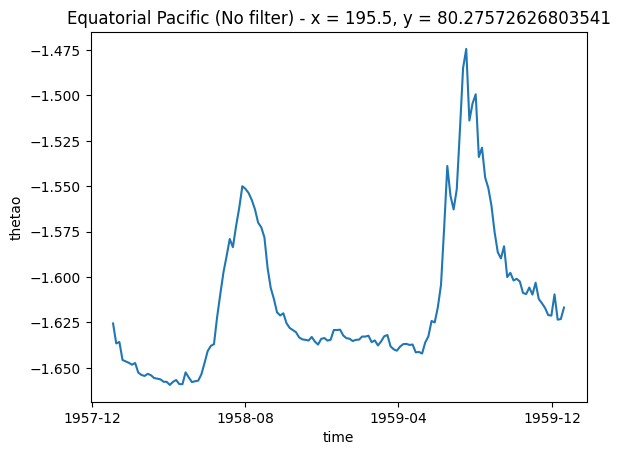

In [10]:
data_loc_single.thetao.plot()
plt.title(f"{location} (No filter) - x = {data_loc_single.x.item()}, y = {data_loc_single.y.item()}")
plt.show()

##### Test fast velocities smoothing

In [12]:
import xarray as xr
data = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr"
)

In [34]:
from dask.diagnostics import ProgressBar

In [35]:
# %matplotlib inline
# import matplotlib.pyplot as plt

In [36]:
window = 30
with ProgressBar():
    data['uo'] = data.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
    data['vo'] = data.vo.rolling(time=window, min_periods=1, center=False).mean().compute()

[########################################] | 100% Completed | 27.31 s
[########################################] | 100% Completed | 27.57 s


In [11]:
with ProgressBar():
    data.to_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1_fast_smoothed_30.zarr", encoding = {v:{'compressor':None} for v in data.variables},
                consolidated=True, mode='w')

[########################################] | 100% Completed | 40.32 s


In [35]:
data.uo

<xarray.DataArray 'uo' (time: 4745, lev: 19, y: 180, x: 360)>
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [-1.25188938e-02, -1.23078530e-02, -1.20940279e-02, ...,
          -1.27280286e-02, -1.27447410e-02, -1.26734536e-02],
         [-1.84597182e-02, -1.80238432e-02, -1.76046994e-02, ...,
          -1.95937431e-02, -1.92579607e-02, -1.88695456e-02],
         [-2.25918577e-02, -2.24962541e-02, -2.24095567e-02, ...,
          -2.27970913e-02, -2.27500207e-02, -2.26925091e-02]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
...
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]]]])
Coordinates:
  * time     (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
  * x        (x) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * y        (y) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
Dimensions without coordinates: lev

In [93]:
# data.sel(x=slice(195, 196), y=slice(50,51)).isel(lev=17).uo.plot()

In [94]:
data_loc = data.sel(x=slice(190, 200), y=slice(-5,5))
location = "Equatorial Pacific"
# data_loc = data.sel(x=slice(190, 200), y=slice(45,55))
# location = "Midlatitudes"
data_loc

<xarray.Dataset>
Dimensions:         (y: 10, x: 10, lev: 19, time: 4745, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 dask.array<chunksize=(5, 10), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(5, 10), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(5, 10), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 10, 10), meta=np.ndarray>
  * time            (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 5, 10), meta=np.ndarray>
  * x               (x) float64 190.5 191.5 192.5 193.5 ... 197.5 198.5 199.5
  * y               (y) float64 -4.488 -3.49 -2.493 -1.496 ... 2.493 3.49 4.488
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 dask.array<chunksize=(1, 10, 10), meta=np.ndarray>
    so              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 10, 10), meta=np.ndarray>
    tauuo           (time, y, x) float32 dask.array<chunksize=(1, 10, 10), meta=np.ndarray>
    tauvo           (time, y, x) float32 dask.array<chunksize=(1, 10, 10), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 10, 10), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 10, 10), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 10, 10), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(1, 10, 10), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

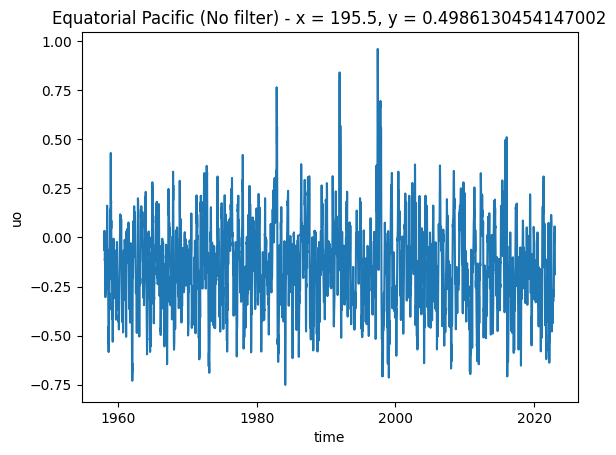

In [95]:
data_loc_single = data_loc.isel(x=5,y=5).isel(lev=0)
data_loc_single.uo.plot()
plt.title(f"{location} (No filter) - x = {data_loc_single.x.item()}, y = {data_loc_single.y.item()}")
plt.show()

In [96]:
import numpy as np
# Create a DataArray with some data
data = xr.DataArray(range(10), dims="time")
print(data)
# Apply rolling mean with a window of 3 and min_periods=1 to avoid NaNs
rolled_data = data.rolling(time=3, min_periods=1, center=False).mean()
rolled_data

<xarray.DataArray (time: 10)>
array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Dimensions without coordinates: time


<xarray.DataArray (time: 10)>
array([0. , 0.5, 1. , 2. , 3. , 4. , 5. , 6. , 7. , 8. ])
Dimensions without coordinates: time

In [97]:
window = 30
data_loc_single['uo'] = data_loc_single.uo.rolling(time=window, min_periods=1, center=False).mean().compute()

In [98]:
data_loc_single.uo

<xarray.DataArray 'uo' (time: 4745)>
array([-0.06364968, -0.05117533, -0.03109554, ..., -0.21640857,
       -0.20942727, -0.20508178], dtype=float32)
Coordinates:
    areacello       float64 dask.array<chunksize=(), meta=np.ndarray>
    dz              int64 dask.array<chunksize=(), meta=np.ndarray>
    lat             float64 dask.array<chunksize=(), meta=np.ndarray>
    lev             float64 2.5
    lon             float64 dask.array<chunksize=(), meta=np.ndarray>
    ocean_fraction  float64 dask.array<chunksize=(), meta=np.ndarray>
  * time            (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
    wetmask         bool dask.array<chunksize=(), meta=np.ndarray>
    x               float64 195.5
    y               float64 0.4986

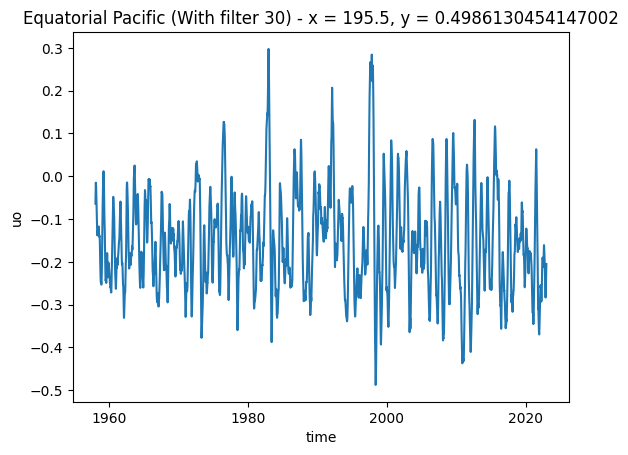

In [99]:
data_loc_single.uo.plot()
plt.title(f"{location} (With filter {window}) - x = {data_loc_single.x.item()}, y = {data_loc_single.y.item()}")
plt.show()

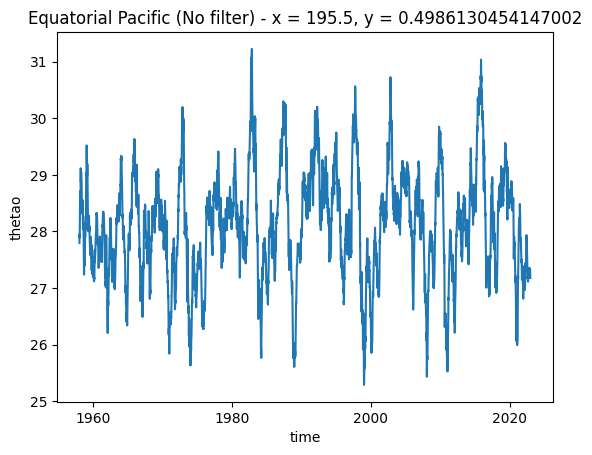

In [100]:
data_loc_single.thetao.plot()
plt.title(f"{location} (No filter) - x = {data_loc_single.x.item()}, y = {data_loc_single.y.item()}")
plt.show()

##### Test Wet

In [35]:
wet = xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1_wetmask")
wet

<xarray.Dataset>
Dimensions:                        (lev: 19, y: 180, x: 360)
Coordinates:
    areacello                      (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz                             (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat                            (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
  * lev                            (lev) float64 2.5 10.0 22.5 ... 5e+03 6e+03
    lon                            (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    ocean_fraction                 (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
    wetmask                        (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x                              (x) float64 0.5 1.5 2.5 ... 357.5 358.5 359.5
  * y                              (y) float64 -89.24 -88.25 ... 88.25 89.24
Data variables:
    __xarray_dataarray_variable__  (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
Attributes:
    __xarray_dataarray_name__:  wetmask

In [36]:
wet.lev.values[0]

2.5

In [37]:
depths = [var.split('lev_')[-1].replace('_', '.') for var in OUT_VARS["3D_all"]]
if 'zos' in depths:
    zos_index = depths.index('zos')
    depths[zos_index] = '2.5'
depths = [float(depth) for depth in depths]
depths
new_wet = wet.sel(lev=depths)
wet = torch.from_numpy(wet.to_array().to_numpy())
wet = torch.concat([wet] * (1 + 1), dim=1)
wet.shape


torch.Size([1, 38, 180, 360])

In [30]:
import torch
wettorch = torch.load("/vast/sd5313/data/m2lines/3D_ocean_data/3D_wet_OM4_5daily_v0.2.1.pt")
(torch.from_numpy(new_wet.to_array().to_numpy()) == wettorch).all()

tensor(True)

In [3]:
data = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/OM4_Horizontal_Regrid_Old.zarr"
)
data

<xarray.Dataset>
Dimensions:  (time: 4745, y: 180, x: 360, lev: 19)
Coordinates:
  * time     (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
  * x        (x) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * y        (y) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
Dimensions without coordinates: lev
Data variables:
    hfds     (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so       (time, lev, y, x) float64 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    tauuo    (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo    (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao   (time, lev, y, x) float64 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo       (time, lev, y, x) float64 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    vo       (time, lev, y, x) float64 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    zos      (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>

In [37]:
data = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/realv00/3D_data_OM4_v0.0"
)
data

<xarray.Dataset>
Dimensions:        (time: 4745, y: 180, x: 360)
Coordinates:
  * time           (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
  * x              (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y              (y) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Data variables: (12/80)
    hfds           (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_0       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_1       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_10      (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_11      (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_12      (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...             ...
    vo_lev_5       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_6       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_7       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_8       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_9       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    zos            (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>

In [12]:
import numpy as np
import torch

# Experiment inputs and outputs
DEPTH_LEVELS = ['2_5',
 '10_0',
 '22_5',
 '40_0',
 '65_0',
 '105_0',
 '165_0',
 '250_0',
 '375_0',
 '550_0',
 '775_0',
 '1050_0',
 '1400_0',
 '1850_0',
 '2400_0',
 '3100_0',
 '4000_0',
 '5000_0',
 '6000_0']

INPT_VARS = {
    "1": ["um", "vm"],
    "2": ["um", "vm", "ur", "vr"],
    "3": ["um", "vm", "Tm"],
    "4": ["um", "vm", "ur", "vr", "Tm", "Tr"],
    "5": ["ur", "vr"],
    "6": ["ur", "vr", "Tr"],
    "7": ["Tm"],
    "8": ["Tm", "Tr"],
    "9": ["u", "v"],
    "10": ["u", "v", "T"],
    "11": ["tau_u", "tau_v"],
    "12": ["tau_u", "tau_v", "t_ref"],
    "3D": ["uo", "vo", "thetao", "so", "zos"],
    "3D_5": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS[:5]
    ]
    + ["zos"],
    "3D_all": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS
    ]
    + ["zos"],
    "3D_SST_all": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS if not (k == "thetao_lev_" and j == DEPTH_LEVELS[0]) 
    ] 
    + ["zos"],
}
EXTRA_VARS = {
    "1": ["ur", "vr"],
    "2": ["ur", "vr", "Tm"],
    "3": ["Tm"],
    "4": ["ur", "vr", "Tm", "Tr"],
    "5": [],
    "6": ["um", "vm"],
    "7": ["um", "vm", "Tm"],
    "8": ["um", "vm", "Tm", "Tr"],
    "9": ["ur", "vr", "tau_u", "tau_v"],
    "10": ["tau_u", "tau_v"],
    "11": ["t_ref"],
    "12": ["tau_u", "tau_v", "t_ref"],
    "13": ["ur", "vr", "Tr", "tau_u", "tau_v", "t_ref"],
    "3D": ["tauuo", "tauvo", "hfds"],
    "3D_5": ["tauuo", "tauvo", "hfds"],
    "3D_all": ["tauuo", "tauvo", "hfds"],
    "3D_SST_all": ["tauuo", "tauvo", "hfds", "thetao_lev_0"],
}
OUT_VARS = {
    "1": ["um", "vm"],
    "2": ["um", "vm", "Tm"],
    "3": ["ur", "vr"],
    "4": ["ur", "vr", "Tr"],
    "5": ["u", "v"],
    "6": ["u", "v", "T"],
    "3D": ["uo", "vo", "thetao", "so", "zos"],
    "3D_5": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS[:5]
    ]
    + ["zos"],
    "3D_all": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS
    ]
    + ["zos"],
    "3D_SST_all": [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in DEPTH_LEVELS if not (k == "thetao_lev_" and j == DEPTH_LEVELS[0]) 
    ] 
    + ["zos"],
}


In [19]:
data

<xarray.Dataset>
Dimensions:        (time: 4745, y: 180, x: 360)
Coordinates:
  * time           (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
  * x              (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y              (y) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Data variables: (12/80)
    hfds           (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_0       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_1       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_10      (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_11      (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_12      (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...             ...
    vo_lev_5       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_6       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_7       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_8       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_9       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    zos            (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>

In [53]:
data = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/3D_data_OM4_v0.0"
)
# mean and std
data_mean = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/3D_data_OM4_v0.0_means"
)
data_std = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/3D_data_OM4_v0.0_stds"
)

# Extract single timestep
data_single = data[INPT_VARS["3D_all"]].isel(time=0)

# Normalize
data_norm = (data_single - data_mean[INPT_VARS["3D_all"]]) / data_std[INPT_VARS["3D_all"]]

# Unnormalize
data_unnorm = data_norm * data_std[INPT_VARS["3D_all"]] + data_mean[INPT_VARS["3D_all"]]

# Verify that the unnormalized data is the same as the original data
assert (data_single - data_unnorm).sum() == 0


In [6]:
data2 = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/3D_data_OM4_v0.0_means"
)
data2

<xarray.Dataset>
Dimensions:            ()
Data variables: (12/80)
    hfds               float64 ...
    so_lev_1050_0      float64 ...
    so_lev_105_0       float64 ...
    so_lev_10_0        float64 ...
    so_lev_1400_0      float64 ...
    so_lev_165_0       float64 ...
    ...                 ...
    vo_lev_5000_0      float64 ...
    vo_lev_550_0       float64 ...
    vo_lev_6000_0      float64 ...
    vo_lev_65_0        float64 ...
    vo_lev_775_0       float64 ...
    zos                float64 ...

In [52]:
import torch 
d1 = torch.load("/vast/sd5313/data/m2lines/3D_ocean_data/3D_wet_OM4_v0.0.pt")
d2 = torch.load("/vast/sd5313/data/m2lines/3D_ocean_data/realv00/3D_wet_OM4_v0.0.pt")
assert (d1 - d2).sum() == 0

d1 = torch.load("/vast/sd5313/data/m2lines/3D_ocean_data/surface_wet_OM4_v0.0.pt")
d2 = torch.load("/vast/sd5313/data/m2lines/3D_ocean_data/realv00/surface_wet_OM4_v0.0.pt")
assert (d1 - d2).sum() == 0

In [16]:
# mean and std
data_mean = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/3D_data_OM4_v0.0_means"
)
data_std = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/3D_data_OM4_v0.0_stds"
)

data_mean2 = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/realv00/3D_data_OM4_v0.0_means"
)
data_std2 = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/realv00/3D_data_OM4_v0.0_stds"
)

In [17]:
data_mean.values == data_mean2.values

False

In [25]:
data_mean[INPT_VARS["3D_all"]].load()

<xarray.Dataset>
Dimensions:            ()
Data variables: (12/77)
    uo_lev_2_5         float64 0.004764
    uo_lev_10_0        float64 0.0033
    uo_lev_22_5        float64 0.005722
    uo_lev_40_0        float64 0.009696
    uo_lev_65_0        float64 0.01151
    uo_lev_105_0       float64 0.01173
    ...                 ...
    so_lev_2400_0      float64 34.76
    so_lev_3100_0      float64 34.76
    so_lev_4000_0      float64 34.74
    so_lev_5000_0      float64 34.72
    so_lev_6000_0      float64 34.71
    zos                float64 -0.1926

In [1]:
ls = [
        k + str(j)
        for k in ["uo_lev_", "vo_lev_", "thetao_lev_", "so_lev_"]
        for j in range(19)
    ]+ ["zos"]
# data_mean2[ls].load()

In [36]:
assert (data_mean[INPT_VARS["3D_all"]].load().to_array().values == data_mean2[ls].load().to_array().values).all()
assert (data_std[INPT_VARS["3D_all"]].load().to_array().values == data_std2[ls].load().to_array().values).all()

In [33]:
import numpy as np
area_weights = np.sqrt(np.cos(np.deg2rad(data.y)))
area_weights

<xarray.DataArray 'y' (y: 180)>
array([0.1154241 , 0.17486379, 0.21891703, 0.25550053, 0.28744627,
       0.31614776, 0.34241137, 0.36675283, 0.38952528, 0.41098292,
       0.43131578, 0.45067022, 0.46916175, 0.48688334, 0.5039111 ,
       0.5203082 , 0.53612775, 0.55141484, 0.56620815, 0.5805411 ,
       0.59444279, 0.60793874, 0.62105142, 0.63380078, 0.64620457,
       0.65827866, 0.67003732, 0.6814934 , 0.69265852, 0.70354324,
       0.71415715, 0.724509  , 0.73460681, 0.7444579 , 0.75406903,
       0.7634464 , 0.77259573, 0.7815223 , 0.79023101, 0.79872638,
       0.80701262, 0.81509363, 0.82297305, 0.83065425, 0.8381404 ,
       0.84543444, 0.85253911, 0.85945698, 0.86619047, 0.87274182,
       0.87911313, 0.8853064 , 0.89132346, 0.89716607, 0.90283585,
       0.90833434, 0.91366299, 0.91882314, 0.92381607, 0.92864297,
       0.93330498, 0.93780315, 0.94213846, 0.94631186, 0.95032423,
       0.95417638, 0.95786909, 0.96140308, 0.96477903, 0.96799758,
       0.97105933, 0.97396483, 0.97671459, 0.9793091 , 0.98174881,
       0.98403413, 0.98616545, 0.98814311, 0.98996745, 0.99163876,
       0.99315729, 0.99452331, 0.99573701, 0.99679859, 0.99770822,
       0.99846603, 0.99907213, 0.99952663, 0.9998296 , 0.99998107,
       0.99998107, 0.9998296 , 0.99952663, 0.99907213, 0.99846603,
       0.99770822, 0.99679859, 0.99573701, 0.99452331, 0.99315729,
       0.99163876, 0.98996745, 0.98814311, 0.98616545, 0.98403413,
       0.98174881, 0.9793091 , 0.97671459, 0.97396483, 0.97105933,
       0.96799758, 0.96477903, 0.96140308, 0.95786909, 0.95417638,
       0.95032423, 0.94631186, 0.94213846, 0.93780315, 0.93330498,
       0.92864297, 0.92381607, 0.91882314, 0.91366299, 0.90833434,
       0.90283585, 0.89716607, 0.89132346, 0.8853064 , 0.87911313,
       0.87274182, 0.86619047, 0.85945698, 0.85253911, 0.84543444,
       0.8381404 , 0.83065425, 0.82297305, 0.81509363, 0.80701262,
       0.79872638, 0.79023101, 0.7815223 , 0.77259573, 0.7634464 ,
       0.75406903, 0.7444579 , 0.73460681, 0.724509  , 0.71415715,
       0.70354324, 0.69265852, 0.6814934 , 0.67003732, 0.65827866,
       0.64620457, 0.63380078, 0.62105142, 0.60793874, 0.59444279,
       0.5805411 , 0.56620815, 0.55141484, 0.53612775, 0.5203082 ,
       0.5039111 , 0.48688334, 0.46916175, 0.45067022, 0.43131578,
       0.41098292, 0.38952528, 0.36675283, 0.34241137, 0.31614776,
       0.28744627, 0.25550053, 0.21891703, 0.17486379, 0.1154241 ])
Coordinates:
  * y        (y) float64 -89.24 -88.25 -87.25 -86.26 ... 86.26 87.25 88.25 89.24
Attributes:
    long_name:  Latitude cell midpoint
    units:      degrees

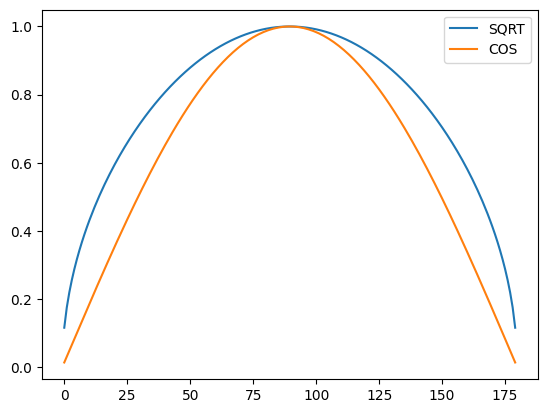

In [38]:
plt.plot(np.sqrt(np.cos(np.deg2rad(data.y))), label="SQRT")
plt.plot(np.cos(np.deg2rad(data.y)), label="COS")
plt.legend()

In [51]:
diff_weights = np.array([3.6734e-01, 3.2146e-01, 2.8054e-01, 2.3014e-01, 1.9086e-01, 1.5179e-01,
        1.3363e-01, 1.3338e-01, 1.3123e-01, 1.3425e-01, 1.4122e-01, 1.5607e-01,
        1.8306e-01, 2.1640e-01, 2.6909e-01, 3.4798e-01, 3.9350e-01, 3.0327e-01,
        1.5722e-01, 6.0882e-01, 5.2569e-01, 4.6328e-01, 3.9356e-01, 3.3616e-01,
        3.0681e-01, 2.7544e-01, 2.4836e-01, 2.4550e-01, 2.5093e-01, 2.7280e-01,
        3.1013e-01, 3.3352e-01, 3.5167e-01, 4.0584e-01, 4.8497e-01, 4.8098e-01,
        3.2968e-01, 1.6328e-01, 1.7627e-02, 1.6149e-02, 1.3806e-02, 1.1896e-02,
        9.5263e-03, 9.8734e-03, 8.9447e-03, 5.9380e-03, 5.4137e-03, 5.3000e-03,
        5.1151e-03, 4.5471e-03, 3.2893e-03, 2.3946e-03, 2.0203e-03, 1.9423e-03,
        2.0582e-03, 1.1031e-03, 3.1544e-04, 2.2664e-02, 1.7673e-02, 1.8266e-02,
        1.2867e-02, 9.1990e-03, 6.7433e-03, 6.5713e-03, 5.3030e-03, 4.1866e-03,
        2.8688e-03, 1.8589e-03, 1.5699e-03, 1.3976e-03, 7.7108e-04, 4.0685e-04,
        5.9043e-04, 8.2559e-04, 7.7413e-04, 2.1697e-04, 3.3815e-02])

In [27]:
temp_weights = np.array([3.6734e-01, 3.2146e-01, 2.8054e-01, 2.3014e-01, 1.9086e-01, 1.5179e-01,
        1.3363e-01, 1.3338e-01, 1.3123e-01, 1.3425e-01, 1.4122e-01, 1.5607e-01,
        1.8306e-01, 2.1640e-01, 2.6909e-01, 3.4798e-01, 3.9350e-01, 3.0327e-01,
        1.5722e-01])

In [6]:
temp_weights = np.array([1.7627e-02, 1.6149e-02, 1.3806e-02, 1.1896e-02,
        9.5263e-03, 9.8734e-03, 8.9447e-03, 5.9380e-03, 5.4137e-03, 5.3000e-03,
        5.1151e-03, 4.5471e-03, 3.2893e-03, 2.3946e-03, 2.0203e-03, 1.9423e-03,
        2.0582e-03, 1.1031e-03, 3.1544e-04])

In [28]:
temp_weights = 1 / temp_weights

In [30]:
# Copy the weights after 12 till the end (cutoff)
# in numpy
temp_weights[12:] = temp_weights[12]


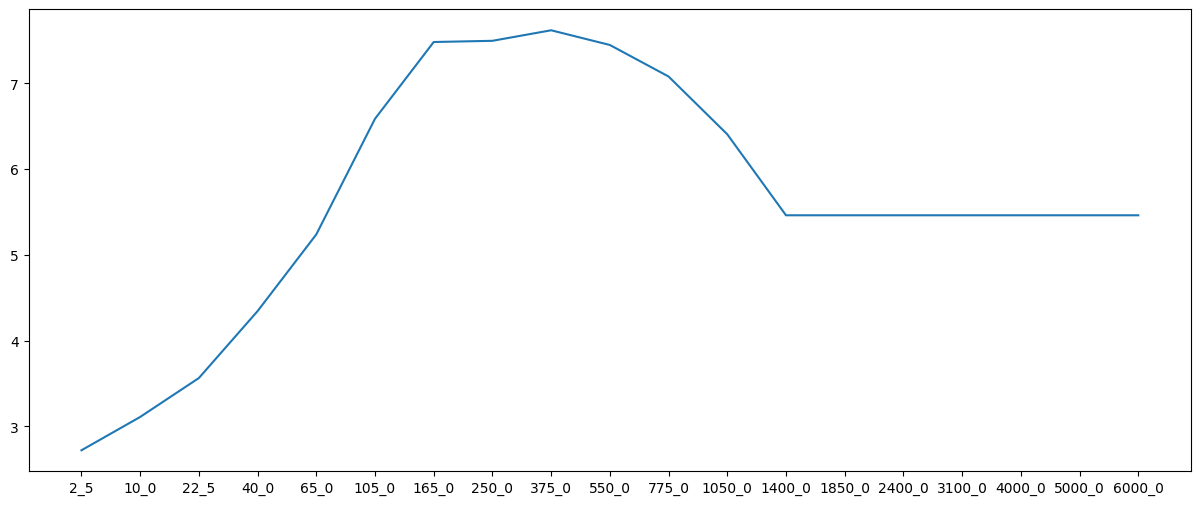

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.plot(DEPTH_LEVELS, temp_weights)